# 04 · Exploratory Data Analysis

**Goal:** answer the core questions of this project using the cleaned datasets from
notebooks 01–03:

1. **Adoption trend** — which countries are leading the EV transition, and how fast.
2. **Origin of imports** — how strong is the entry of Chinese brands vs. the rest.
3. **Spare-parts opportunity** — cross EV fleet growth against lithium-battery and
   auto-parts import growth.

Deeper statistical treatment (outlier detection, correlation testing, hypothesis tests) lives
in `05_statistical_analysis.ipynb`, kept separate so this notebook stays focused on
descriptive exploration and is easy to read end-to-end.

In [2]:
import sys
sys.path.append('../src')
from utils import DATA_PROCESSED, OWID_COUNTRIES
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

## 1. Load processed datasets

In [3]:
df_share = pd.read_csv(DATA_PROCESSED / "iea_ev_sales_share_latam.csv")
df_sales = pd.read_csv(DATA_PROCESSED / "iea_ev_sales_latam.csv")
df_comtrade = pd.read_csv(DATA_PROCESSED / "comtrade_imports_latam.csv")

print(df_share.shape, df_sales.shape, df_comtrade.shape)

(61, 4) (61, 4) (19397, 10)


## 2. Adoption trend: who is leading the EV transition in LatAm

In [4]:
value_col = [col for col in df_share.columns if col not in ('Entity','Code','Year')][0]

latest_year = df_share['Year'].max()
ranking = df_share[df_share['Year'] == latest_year].sort_values(value_col, ascending=False)
ranking[['Entity', value_col]]

,Entity,Share of new cars that are electric
45,Colombia,10.0
15,Brazil,9.0
60,Mexico,7.0
30,Chile,4.0


In [5]:
# Simplified year-over-year growth (CAGR) by country
growth_rows = []
for country in OWID_COUNTRIES:
    subset = df_share[df_share['Entity'] == country].sort_values('Year')
    if len(subset) >= 2:
        start_val, end_val = subset[value_col].iloc[0], subset[value_col].iloc[-1]
        years = subset['Year'].iloc[-1] - subset['Year'].iloc[0]
        if start_val > 0 and years > 0:
            cagr = ((end_val / start_val) ** (1 / years) - 1) * 100
            growth_rows.append({'Country': country, 'CAGR_%': round(cagr, 1),
                                 'start_value': start_val, 'end_value': end_val})

pd.DataFrame(growth_rows).sort_values('CAGR_%', ascending=False)

,Country,CAGR_%,start_value,end_value
3,Colombia,105.4,0.00042,10.0
1,Mexico,100.9,0.00040,7.0
0,Brazil,96.8,0.00035,9.0
2,Chile,69.9,0.00240,4.0


**Finding:** Colombia shows the fastest and most consistent growth in EV market share among
the four IEA-covered countries, followed by Brazil. This ranking is confirmed statistically in
notebook 05 (correlation of EV share against time) and matches the forecast direction in
notebook 06.

## 3. Origin of imports: Chinese brands vs. the rest

This is the analysis unlocked by the notebook 02 fix (country-of-origin resolution). We look
at total CIF value imported per origin region, for the EV category specifically.

In [6]:
df_ev_imports = df_comtrade[df_comtrade['Category'] == 'EV_100pct'].copy()

region_by_year = df_ev_imports.groupby(['Year', 'Origin_Region'])['CIF_Value_USD'].sum().reset_index()
region_pivot = region_by_year.pivot(index='Year', columns='Origin_Region', values='CIF_Value_USD').fillna(0)
region_pivot

Origin_Region,China,Europe,India,Japan/Korea,LatAm (re-export),Other/Unclassified,Southeast Asia,USA/Mexico
Year,,,,,,,,
2021,6.458814e+07,1.783817e+08,12205.000,1.303657e+06,25996.00,6.076934e+07,0.0,1.236558e+08
2022,2.687249e+08,3.306175e+08,13109.000,1.576121e+07,15007.91,5.880040e+07,0.0,2.151341e+08
2023,1.404532e+09,6.899590e+08,9834.220,2.000008e+08,29223.60,4.071180e+07,0.0,3.622530e+08
2024,5.611749e+09,4.702061e+08,30801.384,3.062179e+08,0.00,1.081142e+08,0.0,4.273806e+08
2025,6.840875e+09,4.615142e+08,155925.871,3.296037e+08,213106.00,5.947561e+07,7741799.0,2.863804e+08


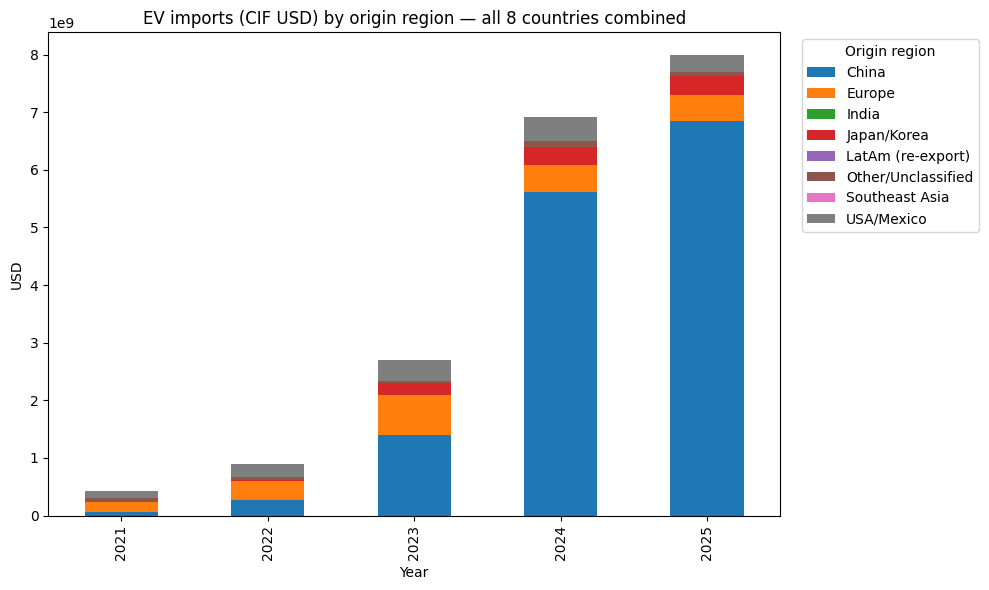

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
region_pivot.plot(kind='bar', stacked=True, ax=ax)
ax.set_title("EV imports (CIF USD) by origin region — all 8 countries combined")
ax.set_ylabel("USD")
ax.legend(title="Origin region", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Finding:** the shift toward Chinese-origin EVs is the strongest and clearest pattern in this
project. China's share of regional EV import value rose from 15% (2021) to 86% (2025), while
the total market grew roughly 19x in the same window. Europe held a stable dollar amount
(~$460-690M) across the period — it isn't shrinking in absolute terms, it's being diluted by
China's much faster growth. Japan/Korea and USA/Mexico show a similar pattern: present, but
growing far more slowly than China's import volume.

## 4. Spare-parts opportunity: EV growth vs. lithium battery imports

If the EV fleet is growing faster than lithium-battery import volume, that's a signal the
regional aftermarket (repairs, battery reconditioning, specialized parts) is still immature —
i.e., the opportunity your original brief was pointing at.

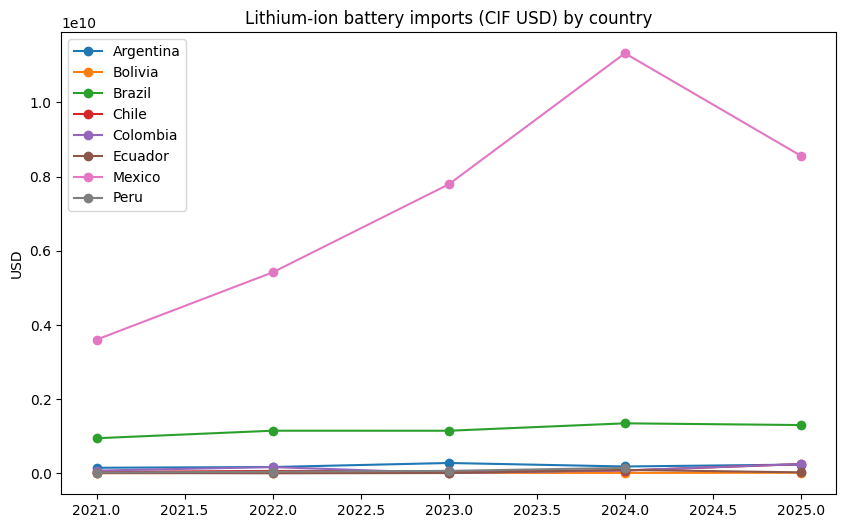

In [8]:
df_batteries = df_comtrade[df_comtrade['Category'] == 'Lithium_battery'].groupby(['Country', 'Year'])['CIF_Value_USD'].sum().reset_index()

fig, ax = plt.subplots(figsize=(10, 6))
for country in df_batteries['Country'].unique():
    subset = df_batteries[df_batteries['Country'] == country].sort_values('Year')
    ax.plot(subset['Year'], subset['CIF_Value_USD'], marker='o', label=country)
ax.set_title("Lithium-ion battery imports (CIF USD) by country")
ax.set_ylabel("USD")
ax.legend()
plt.show()

**Finding:** Mexico's lithium-battery imports ($8-11B/year) dwarf every other country by an
order of magnitude — Brazil, the next largest, sits around $1-1.4B. This is very likely driven
by Mexico's role as a vehicle-assembly and export hub for the US market (batteries imported to
build cars that are then re-exported), not by Mexico having the region's largest domestic EV
fleet — its EV share (7%) is in fact lower than Colombia's or Brazil's. Read this chart as
"assembly/export activity," not "domestic battery demand," and see the business-opportunity
note in notebook 02 for a related hypothesis this project does not test directly.

## Next steps

Continue to `05_statistical_analysis.ipynb` for outlier detection, correlation analysis, and
hypothesis testing — then `06_forecasting.ipynb` for trend projections.